In [150]:
'''
Synchrony and directionality ehibits other transitions that aren't dependent on the 'bursting' transition.

What could these transitions be associated with? 

We might be able to identify these by changing the waveform of the autapse...

'''

"\nSynchrony and directionality ehibits other transitions that aren't dependent on the 'bursting' transition.\n\nWhat could these transitions be associated with? \n\nWe might be able to identify these by changing the waveform of the autapse...\n\n"

In [151]:
from aqua.batchAQUA_general import batchAQUA
from aqua.AQUA_general import AQUA
from aqua.utils import * 
from aqua.plotting_functions import *
from aqua.stimulus import OU_current

'''general imports''' 
import numpy as np
import pandas as pd
from brian2 import *
import matplotlib.pyplot as plt
import seaborn as sns
import pyspike as spk
import pickle
import gc
import tracemalloc
from scipy.signal import convolve, windows
from scipy.stats import wasserstein_distance
from scipy.ndimage import gaussian_filter

from FT_metrics import *
from functions import *

In [152]:
tag = 'identical'
filename = f"burst_analysis_{tag}TRACES.pickle"
with open(filename, 'rb') as file:
    data = pickle.load(file)

print(data.keys())

time = data['time']
N_iter = len(time)
print(N_iter)
dt = time[1] - time[0]
T = N_iter * dt

f_vals = data['f']

spikes_E1 = data['spikes_E1']
spikes_E2 = data['spikes_E2']

bin1 = binarise_spikes(spikes_E1, dt, N_iter)
bin2 = binarise_spikes(spikes_E2, dt, N_iter)

X_E1 = data['X_E1']
X_E2 = data['X_E2']

# Autapse values to inspect
f1 = np.array([0, 50, 60, 70, 75, 80, 85, 90, 95, 100])
idx1_arr = np.array([np.argmin(np.abs(f_vals - f)) for f in f1])

f2 = np.array([0, 215, 220, 228, 231, 240, 245, 260, 280, 445])
idx2_arr = np.array([np.argmin(np.abs(f_vals - f)) for f in f2])



dict_keys(['e', 'f', 'tau', 'time', 'X_E1', 'X_E2', 'I_E1', 'I_E2', 'spikes_E1', 'spikes_E2'])
50000


In [153]:
## Initial plots for the directionality transition at f = 90

split = np.arange(0, 20000, 1)

def plot_leader(idx_arr, bin1, bin2, f_vals, split):
    fig, ax = plt.subplots(1, 1, figsize = (10, 5))


    for n, idx in enumerate(idx_arr):
        ax.plot(time[split], 2.*n + np.cumsum(bin1[idx, split] - bin2[idx, split]), label = f'f = {f_vals[idx]}')
        ax.text(x = -600, y = 2.*n, s = f'f = {np.round(f_vals[idx], 1)}')

    #ax.legend(loc = (1.01, .43))
    ax.set_xlim(-700, 1.1*time[split][-1])

    return fig, ax



(<Figure size 1000x500 with 1 Axes>, <Axes: >)

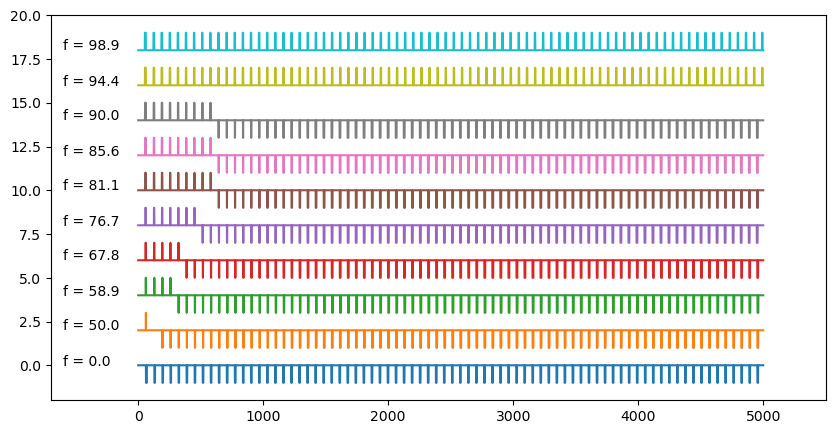

In [154]:
split = np.arange(0, 50000, 1)
plot_leader(idx1_arr, bin1, bin2, f_vals, split)

(<Figure size 1000x500 with 1 Axes>, <Axes: >)

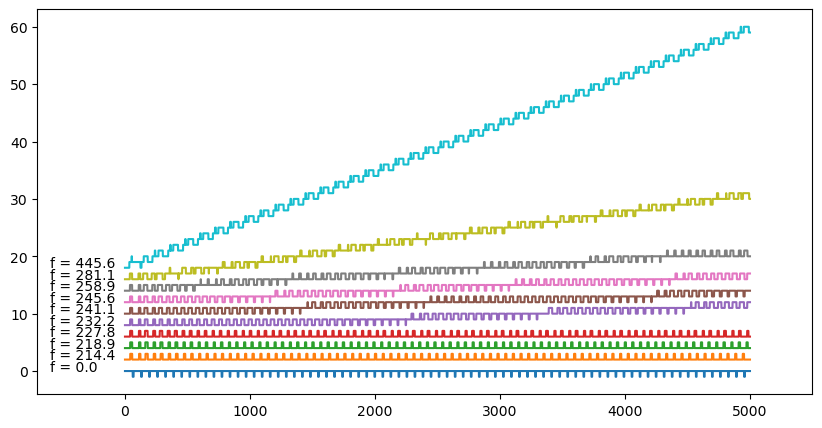

In [155]:
plot_leader(idx2_arr, bin1, bin2, f_vals, split)

[[-60.         -59.801393   -59.60549536 ... -48.68033022 -48.69100161
  -48.70151012]]


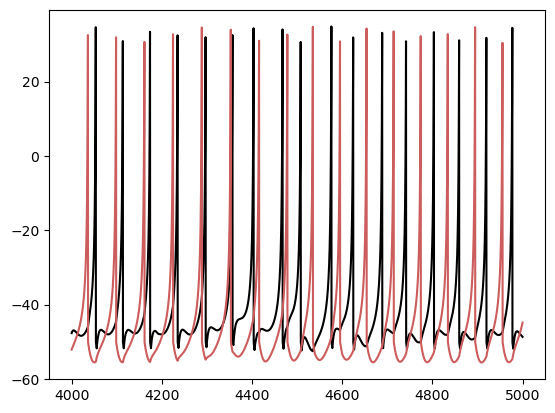

In [156]:
split = np.arange(40000, 50000, 1)
print(X_E1[idx2_arr[np.argwhere(f2 == 245.)[0]]])
plt.plot(time[split], X_E1[idx2_arr[np.argwhere(f2 == 245.)[0]]][0][split], c = 'black')
plt.plot(time[split], X_E2[idx2_arr[np.argwhere(f2 == 245.)[0]]][0][split], c = 'indianred')